In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import glob
from pathlib import Path
import matplotlib.dates as mdates
import calendar
import numpy as np
import matplotlib.cm as cm
from adjustText import adjust_text
import contextily as cx
from pyproj import Geod
from sklearn.linear_model import LinearRegression

In [2]:
# --------------------------- Paths ---------------------------
DATA_DIR = Path("./filtered_data/time_series")
PLOTS_DIR = Path("./UY_basins_S+P+T")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
UYPRECIP_DIR=Path("./precip_uy")
SHAPE_DIR=Path('./watersheds/shapefile')
NAME_ATTRIBUTES=Path('./filtered_data/attributes/attributes.csv')
OUT_TS_DIR = Path("./data/filled_precip")
OUT_TS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
with open("./all_uruguay_basins.txt", "r") as f:
    files = [f"../data/time_series/{line.strip()}.nc" for line in f]

In [4]:
# List all .zip shapefiles except the one containing "mercedes"
zip_files = [f for f in SHAPE_DIR.glob("*.zip") if "mercedes" not in f.stem.lower()]

# Read and combine them into a single GeoDataFrame (optional)
gdfs = []
for zip_file in zip_files:
    gdf = gpd.read_file(f"zip://{zip_file}")
    gdf["source"] = zip_file.stem  # keep track of which shapefile it came from
    gdfs.append(gdf)

combined = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

# Reproject to WGS84 for Folium (required)
combined = combined.to_crs(epsg=4326)

# # Explore interactively (with a background map)
# combined.plot(
#     column="source",          # color by shapefile name
#     cmap="tab20",             # nice color palette
#     legend=True,
#     figsize=(10, 8)
# )

# plt.title("Watersheds by Source")
# plt.show()


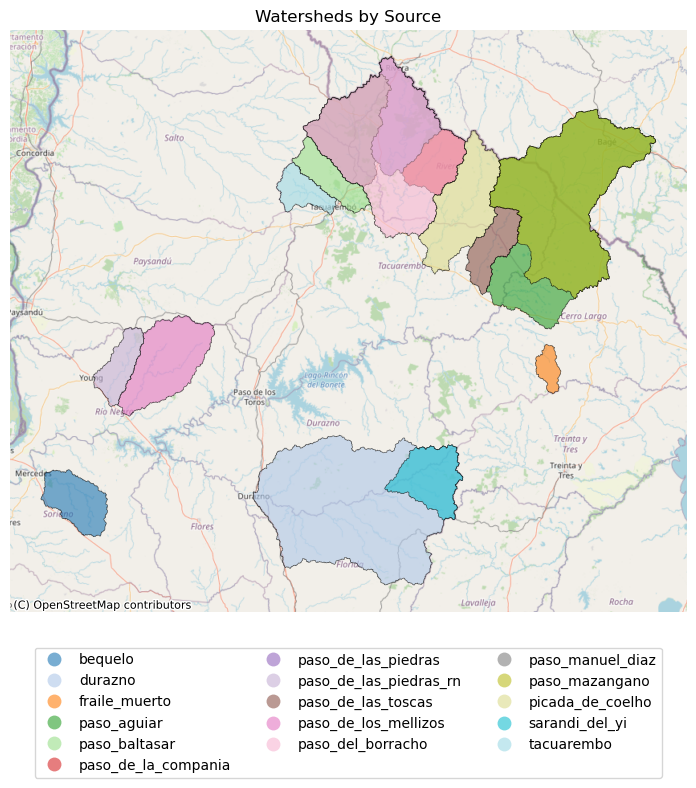

In [5]:
# Reproject to Web Mercator (required for contextily tiles)
combined_wm = combined.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
combined_wm.plot(
    column="source",
    cmap="tab20",
    alpha=0.6,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.05),
        "ncol": 3,  # adjust number of columns as needed
        "frameon": True
    },
    ax=ax
)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
plt.title("Watersheds by Source")
plt.tight_layout()
plt.show()

In [6]:
gauges_coords=pd.read_excel(f'{UYPRECIP_DIR}/COORDENADAS.xlsx')
gauges_coords.head()

,lat,lon,Estacion,Departamento,Tipo,Adm
0,-33.72,-53.55,18 de Julio,Rocha,Convencional,INUMET
1,-34.36,-54.06,19 de Abril,Rocha,Convencional,INUMET
2,-34.41,-56.39,25 de Agosto,Florida,Convencional,INUMET
3,-31.87,-54.16,Acegua,Cerro Largo,Convencional,INUMET
4,-32.40,-56.18,Achar,Tacuarembó,Convencional,INUMET


In [7]:
# --- Load gauges DataFrame ---
# (assuming gauges_coors is already a pandas DataFrame)
gauges_gdf = gpd.GeoDataFrame(
    gauges_coords,
    geometry=gpd.points_from_xy(gauges_coords.lon, gauges_coords.lat),
    crs="EPSG:4326"
)

gauges_gdf.head()

,lat,lon,Estacion,Departamento,Tipo,Adm,geometry
0,-33.72,-53.55,18 de Julio,Rocha,Convencional,INUMET,POINT (-53.55 -33.72)
1,-34.36,-54.06,19 de Abril,Rocha,Convencional,INUMET,POINT (-54.06 -34.36)
2,-34.41,-56.39,25 de Agosto,Florida,Convencional,INUMET,POINT (-56.39 -34.41)
3,-31.87,-54.16,Acegua,Cerro Largo,Convencional,INUMET,POINT (-54.16 -31.87)
4,-32.40,-56.18,Achar,Tacuarembó,Convencional,INUMET,POINT (-56.18 -32.4)


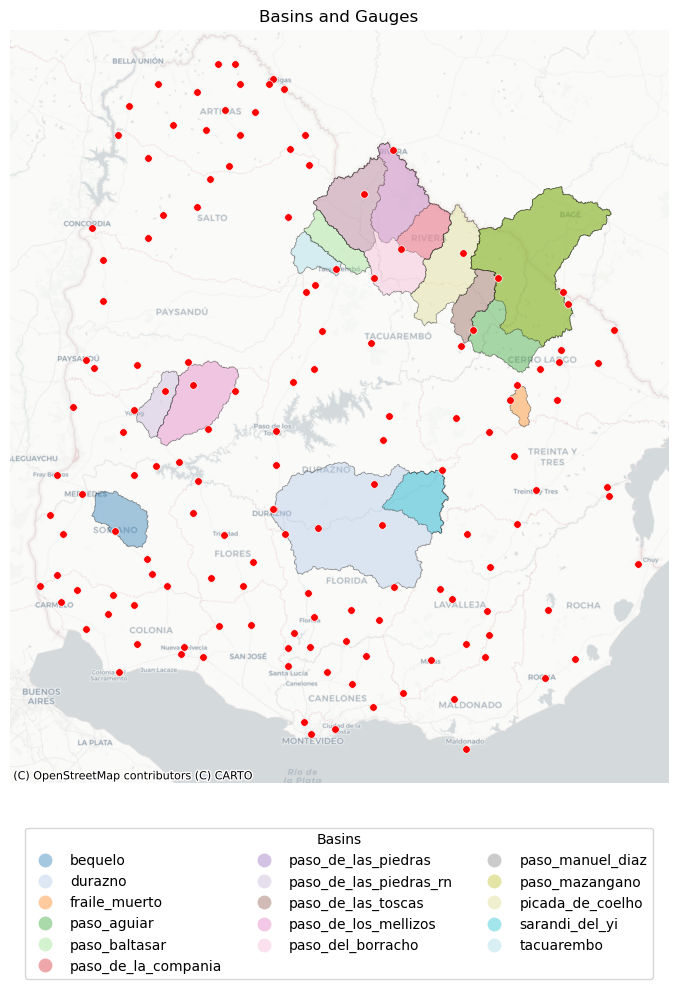

In [8]:
# Reproject both to Web Mercator for contextily
combined_wm = combined.to_crs(epsg=3857)
gauges_wm = gauges_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot basins
combined_wm.plot(
    column="source",
    cmap="tab20",
    alpha=0.4,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.05),
        "ncol": 3,
        "frameon": True,
        "title": "Basins"
    },
    ax=ax
)

# Plot gauges
gauges_wm.plot(
    ax=ax,
    color="red",
    markersize=30,
    edgecolor="white",
    linewidth=0.5,
    label="Gauges",
    zorder=5
)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title("Basins and Gauges")
plt.tight_layout()
plt.show()

In [9]:
# Make sure both are in the same crs
gauges_gdf = gauges_gdf.to_crs(combined.crs)

# #Clipping stations
# gauges_in_basins = gpd.clip(gauges_gdf, combined)

# Spatial join: points get polygon attributes
gauges_in_basins = gpd.sjoin(
    gauges_gdf,
    combined[["source", "geometry"]],
    how="inner",
    predicate="within"
)

gauges_in_basins = gauges_in_basins.rename(
    columns={"source": "basin_source"}
)

gauges_in_basins.head()

,lat,lon,Estacion,Departamento,Tipo,Adm,geometry,index_right,basin_source
16,-33.46,-55.63,Capilla del Sauce,Florida,Convencional,INUMET,POINT (-55.63 -33.46),0,durazno
22,-32.51,-57.16,Canada Grande,Rio Negro,Convencional,INUMET,POINT (-57.16 -32.51),8,paso_de_los_mellizos
47,-32.13,-54.89,Cuchilla Caraguata Norte,Tacuarembó,Convencional,INUMET,POINT (-54.89 -32.13),4,paso_aguiar
50,-31.77,-55.69,Cuchilla del Ombu,Tacuarembó,Convencional,INUMET,POINT (-55.69 -31.77),10,paso_del_borracho
60,-31.71,-56.00,El Molino,Tacuarembó,Convencional,INUMET,POINT (-56 -31.71),15,tacuarembo


In [10]:
print(f"Total gauges before clipping: {len(gauges_gdf)}")
print(f"Total gauges inside basins: {len(gauges_in_basins)}")

Total gauges before clipping: 148
Total gauges inside basins: 17


In [11]:
# Basins that already have at least one gauge
basins_with_gauge = gauges_in_basins['basin_source'].unique()

# Basins missing a gauge
basins_missing = combined.loc[~combined['source'].isin(basins_with_gauge)].copy()
print(f"Basins missing gauges: {len(basins_missing)}")

Basins missing gauges: 5


In [12]:
# Basins that already have at least one gauge
basins_with_gauge = gauges_in_basins['basin_source'].unique()

# Basins missing a gauge
basins_missing = combined.loc[~combined['source'].isin(basins_with_gauge)].copy()
print(f"Basins missing gauges: {len(basins_missing)}")

if len(basins_missing) > 0:
    # use sjoin_nearest: left=basins_missing, right=gauges_gdf
    nearest = gpd.sjoin_nearest(
        basins_missing[['source', 'geometry']],
        gauges_gdf,
        how='left',
        distance_col='dist'
    ).reset_index()

    # Build assigned rows by looking up the matched gauge by index_right
    assigned_rows = []
    for _, row in nearest.iterrows():
        gauge_idx = int(row['index_right'])
        gauge = gauges_gdf.loc[gauge_idx].copy()
        gauge['basin_source'] = row['source']          # assign this basin to that gauge
        gauge['dist_to_basin_m'] = row['dist']         # distance (units of CRS)
        gauge['assigned_nearest'] = True
        assigned_rows.append(gauge)

    assigned_gdf = gpd.GeoDataFrame(assigned_rows).reset_index(drop=True)
    assigned_gdf = assigned_gdf.set_crs(gauges_gdf.crs, allow_override=True)

    # Keep column set consistent with gauges_in_basins (add any missing cols if necessary)
    for c in gauges_in_basins.columns:
        if c not in assigned_gdf.columns:
            assigned_gdf[c] = pd.NA

    # Append and reset index
    gauges_in_basins = pd.concat([gauges_in_basins, assigned_gdf[gauges_in_basins.columns]], ignore_index=True, sort=False)

print(f"Total gauge assignments (original + nearest): {len(gauges_in_basins)}")

Basins missing gauges: 5
Total gauge assignments (original + nearest): 22


/home/azureuser/miniconda3/envs/neuralhydrology/lib/python3.10/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [13]:
gauges_in_basins.head()

,lat,lon,Estacion,Departamento,Tipo,Adm,geometry,index_right,basin_source
0,-33.46,-55.63,Capilla del Sauce,Florida,Convencional,INUMET,POINT (-55.63 -33.46),0,durazno
1,-32.51,-57.16,Canada Grande,Rio Negro,Convencional,INUMET,POINT (-57.16 -32.51),8,paso_de_los_mellizos
2,-32.13,-54.89,Cuchilla Caraguata Norte,Tacuarembó,Convencional,INUMET,POINT (-54.89 -32.13),4,paso_aguiar
3,-31.77,-55.69,Cuchilla del Ombu,Tacuarembó,Convencional,INUMET,POINT (-55.69 -31.77),10,paso_del_borracho
4,-31.71,-56.00,El Molino,Tacuarembó,Convencional,INUMET,POINT (-56 -31.71),15,tacuarembo


In [14]:
# --- Group gauges by basin ---
basin_groups = gauges_in_basins.groupby("basin_source")

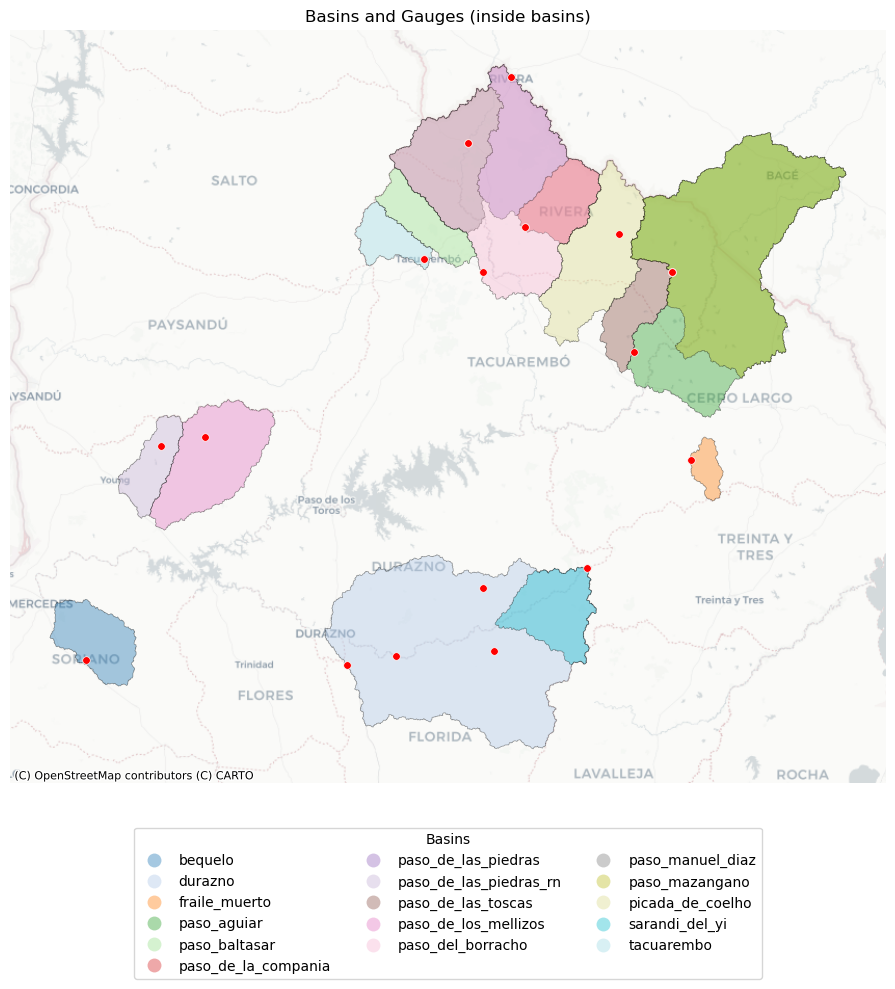

In [15]:
# --- Static map with basemap ---
# Reproject both to Web Mercator for contextily
combined_wm = combined.to_crs(epsg=3857)
gauges_in_basins_wm = gauges_in_basins.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot basins
combined_wm.plot(
    column="source",
    cmap="tab20",
    alpha=0.4,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.05),
        "ncol": 3,
        "frameon": True,
        "title": "Basins"
    },
    ax=ax
)

# Plot gauges
gauges_in_basins_wm.plot(
    ax=ax,
    color="red",
    markersize=30,
    edgecolor="white",
    linewidth=0.5,
    zorder=5
)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title("Basins and Gauges (inside basins)")
plt.tight_layout()
plt.show()

In [16]:
mapping = {
    'paso_de_la_compania': 'CAMELS_UY_1',
    'paso_de_las_piedras': 'CAMELS_UY_2',
    'paso_manuel_diaz': 'CAMELS_UY_3',
    'tacuarembo': 'CAMELS_UY_4',
    'paso_baltasar': 'CAMELS_UY_5',
    'paso_del_borracho': 'CAMELS_UY_6',
    'picada_de_coelho': 'CAMELS_UY_7',
    'paso_de_las_toscas': 'CAMELS_UY_8',
    'paso_aguiar': 'CAMELS_UY_9',
    'paso_mazangano': 'CAMELS_UY_10',
    'fraile_muerto': 'CAMELS_UY_11',
    'sarandi_del_yi': 'CAMELS_UY_12',
    'durazno': 'CAMELS_UY_13',
    'paso_de_los_mellizos': 'CAMELS_UY_14',
    'paso_de_las_piedras_rn': 'CAMELS_UY_15',
    'bequelo': 'CAMELS_UY_16'
}

gauges_in_basins['nc_file_name'] = gauges_in_basins['basin_source'].map(mapping)

In [17]:
gauges_in_basins.head()

,lat,lon,Estacion,Departamento,Tipo,Adm,geometry,index_right,basin_source,nc_file_name
0,-33.46,-55.63,Capilla del Sauce,Florida,Convencional,INUMET,POINT (-55.63 -33.46),0,durazno,CAMELS_UY_13
1,-32.51,-57.16,Canada Grande,Rio Negro,Convencional,INUMET,POINT (-57.16 -32.51),8,paso_de_los_mellizos,CAMELS_UY_14
2,-32.13,-54.89,Cuchilla Caraguata Norte,Tacuarembó,Convencional,INUMET,POINT (-54.89 -32.13),4,paso_aguiar,CAMELS_UY_9
3,-31.77,-55.69,Cuchilla del Ombu,Tacuarembó,Convencional,INUMET,POINT (-55.69 -31.77),10,paso_del_borracho,CAMELS_UY_6
4,-31.71,-56.00,El Molino,Tacuarembó,Convencional,INUMET,POINT (-56 -31.71),15,tacuarembo,CAMELS_UY_4


In [18]:
# estacion_mapping = {
#     "Capilla del Sauce": "Capilla del Sauce 1981-2024",
#     "Cañada Grande": "Canada Grande 1981-2024",
#     "Cuchilla Caragauta N": "Cuchilla Caraguata Norte 1981-2024",
#     "Cuchilla del Ombu": "Cuchilla del Ombu 1982-2024",
#     "El Molino": "El Molino 1981-2024",
#     "Goñi": "Goni 1981-2024",
#     "Minas de Corrales": "Minas de Corrales 1981-2024",  
#     "Moirones": "Moirones 1981-2024",
#     "Palmitas": "Palmitas 1981-2024",
#     "Paso de la Cruz_RN": "Paso de la Cruz_rn 1981-2024",
#     "Polanco del Yi": "Polanco del Yi 1981-2024",
#     "Rossell y Rius": "Rossell y Rius 1981-2024",
#     # "Sarandi del Yi": "", #CSV with gauge precip missing
#     # "Sarandi Grande": "", #CSV with gauge precip missing
#     "Rivera": "Rivera 1981-2024",
#     "Cerro de las Cuentas": "Cerro de las Cuentas 1981-2024",
#     "Cerro Chato": "Cerro Chato 1981-2024",
#     "Tranqueras": "Tranqueras_1982_2024",  
#     "Vichadero": "Vichadero_1981_2024",   
# }

# gauges_in_basins['estacion_file_name'] = gauges_in_basins['Estacion'].map(estacion_mapping)

In [19]:
# gauges_in_basins.head()

In [20]:
# capilla_del_sauce = UYPRECIP_DIR / f"{gauges_in_basins.loc[0, 'estacion_file_name']}.xlsx"
# estacion = gauges_in_basins.loc[0, 'Estacion']
# df = pd.read_excel(capilla_del_sauce)
# df.head()

In [21]:
# estacion

In [22]:
# # Define ellipsoid
# geod = Geod(ellps="WGS84")

# coords = gauges_gdf[["lon", "lat"]].values
# n = len(coords)

# distance_matrix = np.zeros((n, n))

# for i in range(n):
#     for j in range(n):
#         _, _, dist = geod.inv(
#             coords[i][0], coords[i][1],   # lon1, lat1
#             coords[j][0], coords[j][1]    # lon2, lat2
#         )
#         distance_matrix[i, j] = dist  # meters

# distance_matrix = pd.DataFrame(
#     distance_matrix,
#     index=gauges_gdf.Estacion,
#     columns=gauges_gdf.Estacion
# )

In [23]:
# distance_matrix

In [24]:
# # Get the row for this station
# distances = distance_matrix.loc[estacion]

# # Exclude itself (distance = 0)
# distances = distances[distances.index != estacion]

In [25]:
# closest_station = distances.idxmin()
# closest_distance_m = distances.min()

# print(f"Closest gauge to {estacion} is {closest_station}") #, distance: {closest_distance_m:.1f} m

In [26]:
# df_closest = pd.read_excel(UYPRECIP_DIR / f"{closest_station} 1981-2024.xlsx")
# df_closest.head()

In [27]:
# # Convert to datetime
# df["Fecha"] = pd.to_datetime(df["Fecha"])
# df_closest["Fecha"] = pd.to_datetime(df_closest["Fecha"])

# # Set index
# df = df.set_index("Fecha")
# df_closest = df_closest.set_index("Fecha")

In [28]:
# # Replace 'TRAZA' with 0 in both DataFrames
# df["[mm]"] = pd.to_numeric(df["[mm]"].replace("TRAZA", 0), errors="coerce")
# df_closest["[mm]"] = pd.to_numeric(df_closest["[mm]"].replace("TRAZA", 0), errors="coerce")

In [29]:
# combined = df[[ "[mm]" ]].rename(columns={"[mm]": "P_target"}).join(
#     df_closest[[ "[mm]" ]].rename(columns={"[mm]": "P_closest"}),
#     how="inner"  # only keep dates where closest gauge has data
# )

In [30]:
# combined

In [31]:
# combined = combined.dropna(subset=["P_target", "P_closest"])
# combined

In [32]:
# from sklearn.linear_model import LinearRegression
# import numpy as np

# X = combined[["P_closest"]].values  # predictor
# y = combined["P_target"].values     # target

# model = LinearRegression()
# model.fit(X, y)

# print(f"Regression: P_target = {model.intercept_:.2f} + {model.coef_[0]:.2f} * P_closest")

In [33]:
# # First, find dates where your station has missing precipitation:
# # missing_mask = df["[mm]"].isna()
# # df_missing = df.loc[missing_mask]

# missing_mask = df["[mm]"].isna() & df_closest["[mm]"].notna()
# X_missing = df_closest.loc[missing_mask, "[mm]"].values.reshape(-1, 1)
# y_pred = model.predict(X_missing)
# df.loc[missing_mask, "[mm]"] = y_pred

In [34]:
# # Get corresponding closest gauge values:
# X_missing = df_closest.loc[missing_mask, "[mm]"].values.reshape(-1, 1)

In [35]:
# X_missing

In [36]:
# # predict
# y_pred = model.predict(X_missing)

In [37]:
# df.loc[missing_mask, "[mm]"] = y_pred

In [38]:
estaciones=gauges_in_basins["Estacion"].unique()
estaciones

array(['Capilla del Sauce', 'Canada Grande', 'Cuchilla Caraguata Norte',
       'Cuchilla del Ombu', 'El Molino', 'Goni', 'Minas de Corrales',
       'Moirones', 'Palmitas', 'Paso de la Cruz_rn', 'Polanco del Yi',
       'Rossell y Rius', 'Tranqueras', 'Vichadero', 'Rivera',
       'Cerro de las Cuentas', 'Cerro Chato'], dtype=object)

In [40]:
estaciones=estaciones[2:]
estaciones

array(['Cuchilla Caraguata Norte', 'Cuchilla del Ombu', 'El Molino',
       'Goni', 'Minas de Corrales', 'Moirones', 'Palmitas',
       'Paso de la Cruz_rn', 'Polanco del Yi', 'Rossell y Rius',
       'Tranqueras', 'Vichadero', 'Rivera', 'Cerro de las Cuentas',
       'Cerro Chato'], dtype=object)

In [41]:
# # --- Get station name ---
# estacion = gauges_in_basins.loc[0, 'Estacion']
for estacion in estaciones:
    # --- Find the Excel file using a pattern ---
    pattern = str(UYPRECIP_DIR / f"*{estacion}*.xlsx")
    matching_files = glob.glob(pattern)

    if len(matching_files) == 0:
        raise FileNotFoundError(f"No file found for station {estacion}")
    elif len(matching_files) > 1:
        print(f"Warning: multiple files found for {estacion}, using the first one")

    capilla_del_sauce = matching_files[0]

    # --- Read the Excel file ---
    df = pd.read_excel(capilla_del_sauce)

    # --- Identify columns ---
    precip_col = [c for c in df.columns if "[mm]" in c][0]
    coment_col = [c for c in df.columns if "Comentario" in c][0]

    # Convert 'TRAZA' to 0 and numeric
    df[precip_col] = pd.to_numeric(df[precip_col].replace("TRAZA", 0), errors="coerce")

    #Make sure there are not any missing dates
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    all_dates = pd.date_range(start=df["Fecha"].min(), end=df["Fecha"].max(), freq="D")
    df = df.set_index("Fecha").reindex(all_dates)
    df.index.name = "Fecha"

    # --- Compute geodesic distances ---
    geod = Geod(ellps="WGS84")
    coords = gauges_gdf[["lon", "lat"]].values
    station_names = gauges_gdf["Estacion"]

    n = len(coords)
    distance_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            _, _, dist = geod.inv(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            distance_matrix[i, j] = dist

    distance_matrix = pd.DataFrame(distance_matrix, index=station_names, columns=station_names)

    # --- Order all other gauges by distance ---
    distances = distance_matrix.loc[estacion].sort_values()
    distances = distances[distances.index != estacion]  # exclude self
    ordered_gauges = distances.index.tolist()

    # --- Fill missing precipitation using nearest available gauge ---
    for date in df[df[precip_col].isna()].index:
        # try each gauge in order
        for g in ordered_gauges:

            # Use wildcard to match any file containing the gauge name
            pattern = str(UYPRECIP_DIR / f"*{g}*.xlsx")
            matching_files = glob.glob(pattern)

            if len(matching_files) == 0:
                # No file found for this gauge, try next
                continue
            elif len(matching_files) > 1:
                print(f"Warning: multiple files found for {g}, using the first one")

            gauge_file = matching_files[0]

            df_g = pd.read_excel(gauge_file)

            # Detect gauge-specific columns
            precip_col_g = [c for c in df_g.columns if "[mm]" in c][0]
            coment_col_g = [c for c in df_g.columns if "Comentario" in c][0]

            df_g[precip_col_g] = pd.to_numeric(df_g[precip_col_g].replace("TRAZA", 0), errors="coerce")

            #Make sure there are not any missing dates
            df_g["Fecha"] = pd.to_datetime(df_g["Fecha"])
            all_dates = pd.date_range(start=df_g["Fecha"].min(), end=df_g["Fecha"].max(), freq="D")
            df_g = df_g.set_index("Fecha").reindex(all_dates)
            df_g.index.name = "Fecha"

            if date in df_g.index and not pd.isna(df_g.loc[date, precip_col_g]):
                # predictor available, fit regression on overlapping dates
                combined = df[[ precip_col ]].rename(columns={precip_col: "P_target"}).join(
                    df_g[[ precip_col_g ]].rename(columns={precip_col_g: "P_closest"}),
                    how="inner"
                ).dropna()

                X_train = combined[["P_closest"]].values
                y_train = combined["P_target"].values

                if len(X_train) == 0:
                    # no overlapping data to fit regression, skip to next gauge
                    continue

                model = LinearRegression()
                model.fit(X_train, y_train)

                # predict for this missing day
                X_pred = np.array([[df_g.loc[date, precip_col_g]]])
                y_pred = model.predict(X_pred)
                df.loc[date, precip_col] = y_pred[0]

                # --- Add a flag in Comentario ---
                df.loc[date, coment_col] = f"Filled via regression from {g}"
                
                break  # move to next missing date

    # --- Result: df now has missing values filled where possible ---
    print(f"Missing values for {estacion} after filling", df[precip_col].isna().sum())

    df.to_excel(OUT_TS_DIR / f"{estacion}_filled_precip.xlsx")

Missing values for Cuchilla Caraguata Norte after filling 0


ValueError: cannot reindex on an axis with duplicate labels